In [28]:
import os
import h5py
import numpy as np
import torch
from torch_geometric.data import Data

# ====================== 1. 定义相对路径（完全匹配你的目录） ======================
# 脚本路径：data/scripts → 数据路径：data/dataset/G_emb.npy（MATLAB 7.3格式）
file_rel_path = "../dataset/G_emb.npy"
file_abs_path = os.path.abspath(file_rel_path)

# 验证文件存在
if not os.path.exists(file_rel_path):
    raise FileNotFoundError(f"文件不存在！路径：{file_abs_path}")

# ====================== 2. 读取数值矩阵（适配你的.Variables提取的array） ======================
with h5py.File(file_rel_path, 'r') as f:
    # --------------------------
    # 1. 读取边的源/目标节点（src/tgt，0-based数值）
    # --------------------------
    # MATLAB列优先 → Python行优先，转置+降维（去除多余维度）
    src = np.squeeze(np.array(f['src']).T)  # 一维数组 (11645,)
    tgt = np.squeeze(np.array(f['tgt']).T)  # 一维数组 (11645,)
    # 构建PyG要求的edge_index（2×E矩阵，第一行源、第二行目标）
    edge_index = np.vstack([src, tgt])      # 维度：(2, 11645)
    
    # --------------------------
    # 2. 读取节点特征矩阵（nodeFeat：.Variables提取的数值矩阵）
    # --------------------------
    # 转置匹配维度（MATLAB列优先→Python行优先），去除冗余维度
    nodeFeat = np.squeeze(np.array(f['nodeFeat']).T)  # 维度：(4301, N)（N为节点特征数）
    
    # --------------------------
    # 3. 读取边特征矩阵（edgeFeat：.Variables提取的数值矩阵）
    # --------------------------
    edgeFeat = np.squeeze(np.array(f['edgeFeat']).T)  # 维度：(11645, M)（M为边特征数）

# ====================== 3. 转换为PyG张量（构建有向图） ======================
# 核心要求：
# - edge_index必须为torch.int64（PyG强制）
# - 节点/边特征为torch.float32（深度学习常用格式）
edge_index = torch.tensor(edge_index, dtype=torch.int64)
x = torch.tensor(nodeFeat, dtype=torch.float32)          # 节点特征 (4301, N)
edge_attr = torch.tensor(edgeFeat, dtype=torch.float32)  # 边特征 (11645, M)

# 构建PyG有向图（天然支持有向，核心是edge_index的方向）
graph_pyg = Data(
    x=x,                # 节点特征矩阵（.Variables提取的数值）
    edge_index=edge_index,  # 有向边索引（src→tgt）
    edge_attr=edge_attr     # 边特征矩阵（.Variables提取的数值）
)

# ====================== 4. 验证读取结果（匹配你的数据维度） ======================
print("===== 读取结果验证 =====")
print(f"文件路径：{file_abs_path}")
print(f"edge_index维度：{edge_index.shape}")  # 预期 (2, 11645)
print(f"节点特征维度：{x.shape}")            # 预期 (4301, 特征数)
print(f"边特征维度：{edge_attr.shape}")      # 预期 (11645, 特征数)
print(f"PyG有向图节点数：{graph_pyg.num_nodes}")  # 4301（由x的行数自动推断）
print(f"PyG有向图边数：{graph_pyg.num_edges}")    # 11645
print(f"是否为有向图：{graph_pyg.is_directed()}") # True

===== 读取结果验证 =====
文件路径：e:\我的文件\大学学习\_硕士学习\毕设硕士\车辆控制算法开发\Compass-Predictive-Driving\data\dataset\G_emb.npy
edge_index维度：torch.Size([2, 11645])
节点特征维度：torch.Size([4301, 14])
边特征维度：torch.Size([11645, 2])
PyG有向图节点数：4301
PyG有向图边数：11645
是否为有向图：True


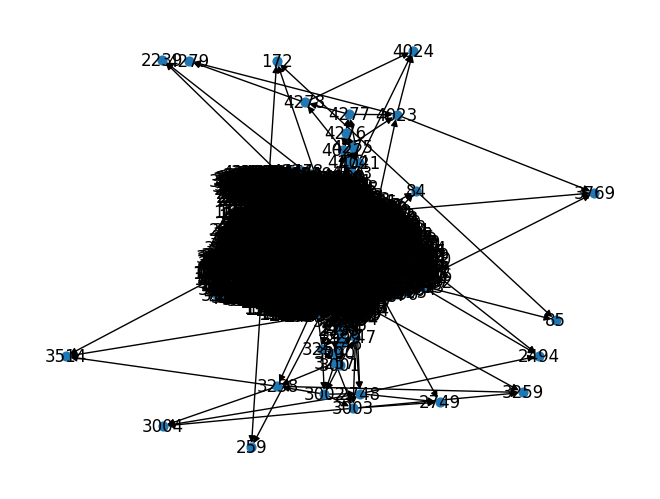

In [10]:
# 可视化有向图
import networkx as nx

# 将graph_pyg转换为networkx图
G = nx.DiGraph()

# 添加节点
G.add_nodes_from(range(graph_pyg.x.shape[0]))

# 添加边
edge_index = graph_pyg.edge_index.numpy()
G.add_edges_from(edge_index.T)

# 绘制图形
pos = nx.spring_layout(G) 
nx.draw(G, pos, with_labels=True, node_size=40)



In [7]:

print(graph_pyg)

Data(edge_index=[2, 11645], node_var_names=[60214], edge_var_names=[23290])


In [11]:
pos

{0: array([0.33807793, 0.02354922]),
 1: array([0.32600132, 0.05636873]),
 2: array([0.29953212, 0.08908127]),
 3: array([0.2642169 , 0.11933506]),
 4: array([0.22207069, 0.14571977]),
 5: array([0.17795695, 0.16079845]),
 6: array([0.13033502, 0.16882549]),
 7: array([0.07925927, 0.16839027]),
 8: array([0.02656685, 0.15847197]),
 9: array([-0.02023048,  0.13711523]),
 10: array([-0.06476671,  0.10864491]),
 11: array([-0.10527665,  0.07515253]),
 12: array([-0.14884284,  0.03828181]),
 13: array([-0.1931255 ,  0.00220881]),
 14: array([-0.24137653, -0.02690068]),
 15: array([-0.29085311, -0.03884658]),
 16: array([-0.28568038, -0.02330846]),
 17: array([-0.25378227, -0.01849391]),
 18: array([-0.21108875, -0.01136671]),
 19: array([-0.16770595, -0.00808137]),
 20: array([-0.13164777, -0.00731918]),
 21: array([-0.08901647, -0.00683645]),
 22: array([-0.04718701, -0.00517122]),
 23: array([-0.00369235, -0.00460225]),
 24: array([ 0.04026464, -0.0036951 ]),
 25: array([0.08281428, 0.00

In [19]:
graph_pyg.x

tensor([[5.9678e+04, 8.6850e+04, 2.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.9678e+04, 8.6847e+04, 2.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.9678e+04, 8.6845e+04, 2.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [5.9944e+04, 8.6609e+04, 1.0000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.9945e+04, 8.6609e+04, 1.0000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.9945e+04, 8.6610e+04, 1.0000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])

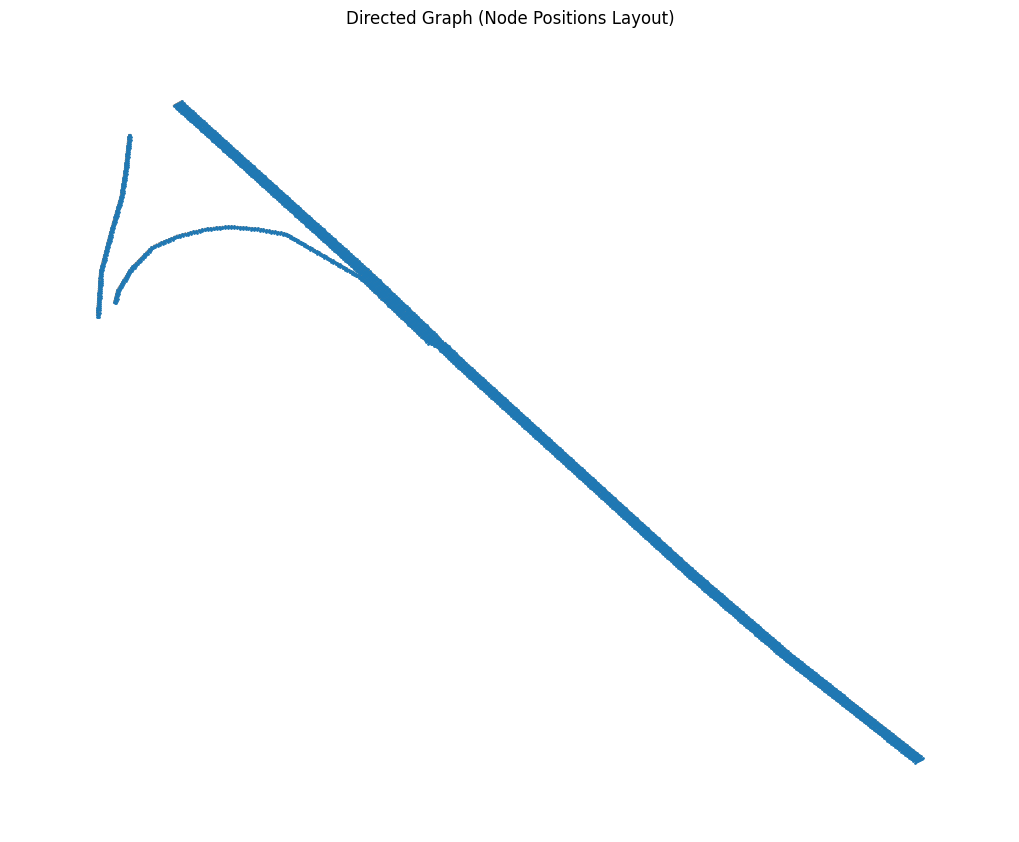

In [29]:
# 可视化有向图
import networkx as nx
import matplotlib.pyplot as plt

# 将graph_pyg转换为networkx图
G = nx.DiGraph()

# 添加节点
num_nodes = graph_pyg.x.shape[0]
G.add_nodes_from(range(num_nodes))

# 添加边
edge_index = graph_pyg.edge_index.numpy()
G.add_edges_from(edge_index.T)

# ====================== 核心：将graph_pyg.x的前两列转换为pos格式 ======================
# 1. 提取x的前两列（节点物理位置），转换为numpy数组
# （若tensor在GPU上，需先加.cpu()，如：graph_pyg.x[:, :2].cpu().detach().numpy()）
node_positions = graph_pyg.x[:, :2].detach().numpy()

# 2. 构建pos字典：键=节点索引，值=对应坐标数组
pos = {}
for node_idx in range(num_nodes):
    pos[node_idx] = node_positions[node_idx]  # 每个节点对应前两列的坐标

# ====================== 绘制图形 ======================
plt.figure(figsize=(10, 8))  # 调整画布大小，避免节点重叠
nx.draw(
    G, 
    pos=pos,          # 使用转换后的物理位置pos
    with_labels=False, # 节点数量多的话建议关闭标签（避免混乱）
    node_size=1,     # 节点大小
    edge_color="#888888", # 边颜色浅一点，突出节点
    arrowsize=1       # 有向边箭头大小
)
plt.title("Directed Graph (Node Positions Layout)")
plt.show()



In [12]:
import os
import h5py
import numpy as np
import torch
from torch_geometric.data import Data

# ====================== 1. 定义相对路径 ======================
file_rel_path = "../dataset/rawmat/LygYc_no10_3500_merge_3_2025-12-28_12-59-55_205.mat"


def read_graph_sample(file_rel_path,verbose=True):
    # ====================== 2. 读取数值矩阵 ======================
    with h5py.File(file_rel_path, 'r') as f:
        # --------------------------
        # 1. 读取边的源/目标节点（src/tgt，0-based数值）
        # --------------------------
        # MATLAB列优先 → Python行优先，转置+降维（去除多余维度）
        edge_index = np.squeeze(np.array(f['endNodes'])) - 1  # 转换为0-based索引

        # 转置匹配维度（MATLAB列优先→Python行优先），去除冗余维度
        nodeStatFeat = np.squeeze(np.array(f['nodeStatFeats']).T)  # 
        nodeDynFeat = np.squeeze(np.array(f['nodeDynFeats']).T)  # 
        
        # --------------------------
        # 3. 读取边特征矩阵（edgeFeat：.Variables提取的数值矩阵）
        # --------------------------
        edgeFeat = np.squeeze(np.array(f['edgeFeats']).T)  # 
        # edgeNum = np.squeeze(np.array(f['edges_num']))  #
        node_idx_list = np.squeeze(np.array(f['nodes_idx_list']))  #

    
    graph_series = [] # 这里面用来存储时序上的图元素
    for i in range(node_idx_list.shape[0]-1):

        # ====================== 3. 转换为PyG张量（构建有向图） ======================
        # 核心要求：
        # - edge_index必须为torch.int64（PyG强制）
        # - 节点/边特征为torch.float32（深度学习常用格式）
        edge_index = torch.tensor(edge_index, dtype=torch.int64)
        nodes_idx = np.arange(0, nodeStatFeat.shape[0]) + nodeStatFeat.shape[0]*i
        x = torch.tensor(np.concatenate((nodeStatFeat, nodeDynFeat[nodes_idx, :]), axis=1), dtype=torch.float32)          # 节点特征 (N, 特征数)
        edge_attr = torch.tensor(edgeFeat, dtype=torch.float32)  # 边特征 (11645, M)
        
        # 构建PyG有向图（天然支持有向，核心是edge_index的方向）
        graph_pyg = Data(
            x=x,                # 节点特征矩阵（.Variables提取的数值）
            edge_index=edge_index,  # 有向边索引（src→tgt）
            edge_attr=edge_attr     # 边特征矩阵（.Variables提取的数值）
        )
        graph_series.append(graph_pyg)
        
    if verbose:
        # ====================== 4. 验证读取结果（匹配你的数据维度） ======================
        print("===== 读取结果 =====")
        print(f"文件路径：{file_abs_path}")
        print(f"读取图数量：{len(graph_series)}")
        print(f"edge_index维度：{edge_index.shape}")  # 预期 (2, 11645)
        print(f"节点特征维度：{x.shape}")            # 预期 (4301, 特征数)
        print(f"边特征维度：{edge_attr.shape}")      # 预期 (11645, 特征数)
        print(f"PyG有向图节点数：{graph_pyg.num_nodes}")  # 4301（由x的行数自动推断）
        print(f"PyG有向图边数：{graph_pyg.num_edges}")    # 11645
        print(f"是否为有向图：{graph_pyg.is_directed()}") # True
    
    return graph_series
        
graph_series = read_graph_sample(file_rel_path)


===== 读取结果 =====
文件路径：e:\我的文件\大学学习\_硕士学习\毕设硕士\车辆控制算法开发\Compass-Predictive-Driving\data\dataset\rawmat\LygYc_no10_3500_merge_3_2025-12-28_12-59-55_205.mat
读取图数量：41
edge_index维度：torch.Size([2, 14840])
节点特征维度：torch.Size([5673, 15])
边特征维度：torch.Size([14840, 2])
PyG有向图节点数：5673
PyG有向图边数：14840
是否为有向图：True


D:\Temp\ipykernel_95488\3227966307.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(edge_index, dtype=torch.int64)


支持的颜色映射：'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_graph(graph_pyg, feature, cmap_style="viridis", node_display_size=3, plot_alpha=0.9):
    feat_trans_name_dict = {
        'x': 1, 'y': 2,
        'node_type': 3, 'free_end': 4, 'laneno': 5,
        'roadtype': 6, 'spdlim': 7, 'drivable': 8,
        'occ': 9, 'vtype': 10, 'spd': 11, 'speed': 11,
        'acc': 12, 'head': 13,'heading':13, 'ego': 14, 'route': 15
    }
    # ====================== 1. 核心配置区（⭐ 改这里即可切换特征/配色，按需修改） ======================
    # ✅ 选择要映射颜色的特征（填写【MATLAB索引】即可，自动转Python索引）
    # 对应规则：MATLAB 1(x)、2(y)、3(node_type)、4(free_end)、5(laneno)、6(roadtype)、7(spdlim)、8(drivable)
    #           MATLAB 9(occ)、10(vType)、11(spd)、12(acc)、13(head)、14(ego)、15(route)
    if feature in feat_trans_name_dict:
        color_map_matlab_idx = feat_trans_name_dict[feature] # 示例：选MATLAB11 → 速度spd，映射颜色；可改3/5/9/14等任意值
    else:
        color_map_matlab_idx = 7
    
    # cmap_style = "viridis"     # 配色盘，可选：viridis/plasma/coolwarm/rainbow/Set3/turbo等
    # node_display_size = 3      # 节点大小，和原代码node_size保持一致
    # plot_alpha = 0.9           # 节点透明度（0~1），高密度节点建议0.6~0.9

    # ====================== 2. 数据预处理（兼容GPU张量+解耦，通用写法） ======================
    # 提取graph_pyg.x的所有特征，转为numpy数组（GPU→CPU兼容）
    if torch.cuda.is_available() and graph_pyg.x.is_cuda:
        node_feat_np = graph_pyg.x.cpu().detach().numpy()  # GPU张量转CPU再转numpy
    else:
        node_feat_np = graph_pyg.x.detach().numpy()        # CPU张量直接转numpy

    # ✅ 精准提取数据（严格对应你的MATLAB索引规则）
    x_coords = node_feat_np[:, 0]   # MATLAB1 → Python0：节点X坐标
    y_coords = node_feat_np[:, 1]   # MATLAB2 → Python1：节点Y坐标
    # 特征索引转换：MATLAB(1开始) → Python(0开始)，自动计算无需手动改
    color_feat_vals = node_feat_np[:, color_map_matlab_idx - 1]  

    # ====================== 3. 特征-颜色映射 核心绘图（scatter散点图） ======================
    plt.figure(figsize=(16, 10), dpi=100)  # 画布尺寸+分辨率优化，适配路网可视化
    scatter = plt.scatter(
        x=x_coords,
        y=y_coords,
        s=node_display_size,       # 节点大小，和原代码一致
        c=color_feat_vals,         # ✅ 核心：特征值映射颜色
        cmap=cmap_style,           # ✅ 配色盘选择
        alpha=plot_alpha,          # 透明度，解决节点重叠遮挡问题
        edgecolors="none",          # 关闭节点边框，提升可视化质感
    )

    # ====================== 4. 关键美化+辅助配置（必加，可视化更专业） ======================
    # 添加颜色条（联动特征值与颜色，必备！）
    cbar = plt.colorbar(scatter, shrink=0.8)
    # 自动生成颜色条标题（显示当前映射的特征名称）
    feat_name_dict = {1: "X Position", 2: "Y Position",
        3: "Node Type", 4: "Free Ends", 5: "Lane Number",
        6: "Road Type", 7: "Speed Limit", 8: "Drivable Area",
        9: "Vehicle Occupancy", 10: "Vehicle Type", 11: "Vehicle Speed",
        12: "Vehicle Acc", 13: "Vehicle Heading", 14: "Ego Occupancy", 15: "Route Index"
    }

    cbar.set_label(feat_name_dict.get(color_map_matlab_idx, f"feature-MATLAB index{color_map_matlab_idx}"), fontsize=12)

    # 图形标题（自动显示当前可视化的特征）
    plt.title(f"Node Scatter Visualization | Color mapped to: {feat_name_dict.get(color_map_matlab_idx, 'Custom Feature')}", 
            fontsize=14, pad=20)

    # 关闭坐标轴（路网可视化无需坐标刻度，更简洁）
    plt.axis('off')
    # 让横纵坐标轴尺度一致，避免 distortion
    plt.axis('equal')
    # 紧凑布局，避免颜色条/标题溢出
    plt.tight_layout()

    # 显示图形
    plt.show()

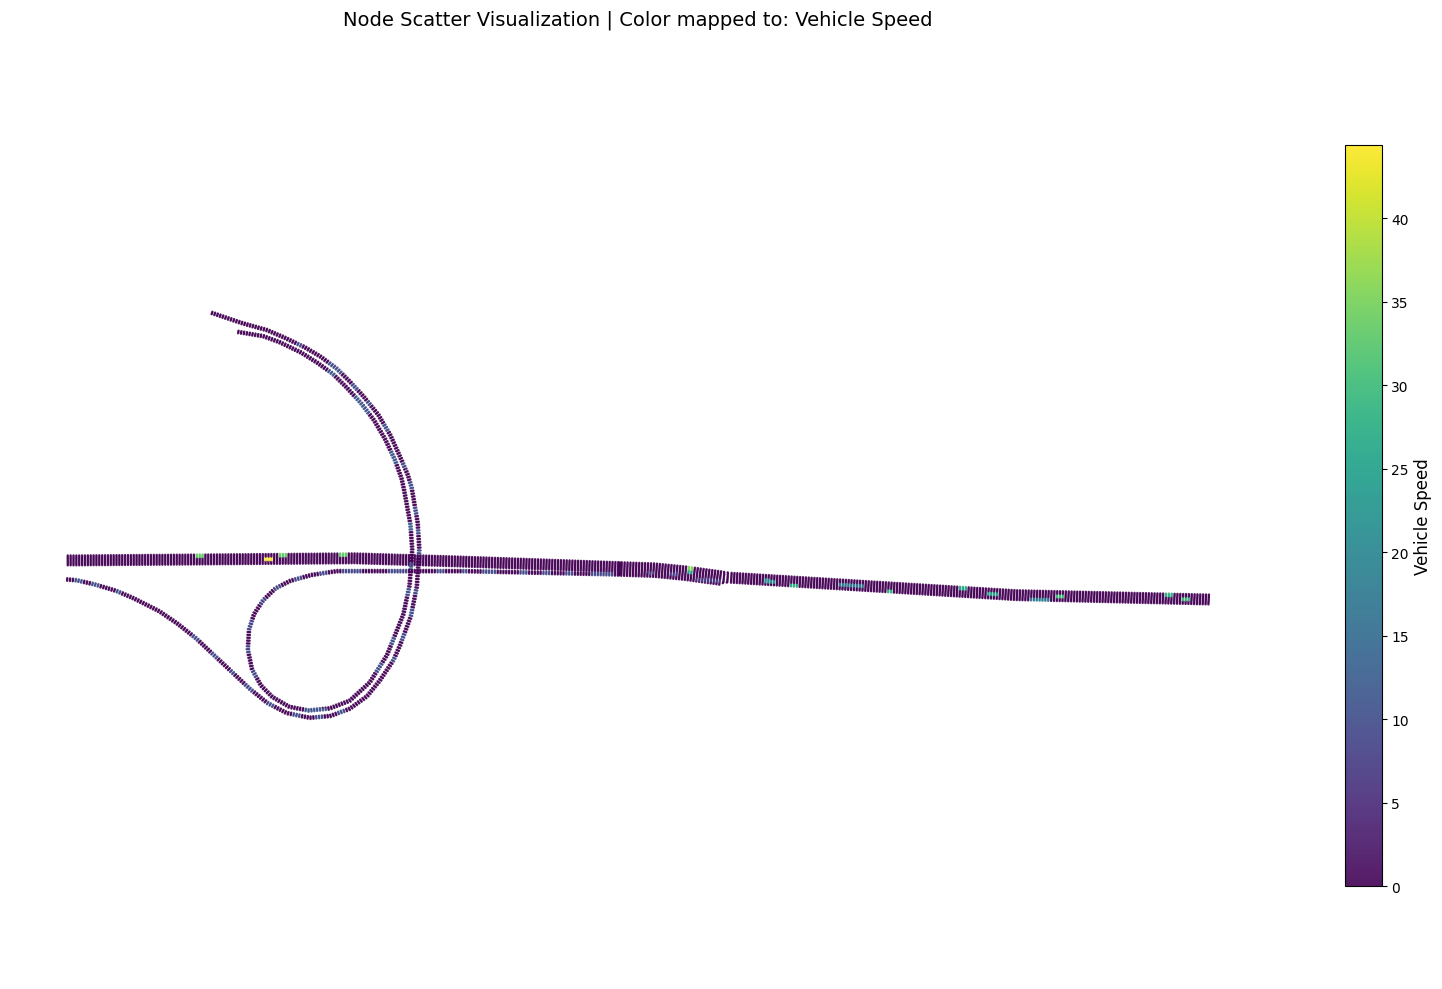

In [15]:
plot_graph(graph_series[40],'spd')


In [ ]:
# # ====================== 1. 定义相对路径 ======================
# file_rel_path = "data/dataset/CompassGraphDataset/raw/LygYc_no10_3500_merge_3_2025-12-28_12-59-55_205.mat"

# graph_series = read_graph_sample(file_rel_path)

# for i in range(len(graph_series)):
#     plot_graph(graph_series[i],'spd')

In [22]:
x = torch.randint(0,10,(10,3))
x

tensor([[7, 4, 6],
        [0, 9, 3],
        [7, 0, 4],
        [5, 0, 9],
        [9, 9, 6],
        [1, 3, 8],
        [5, 2, 4],
        [4, 5, 5],
        [0, 5, 1],
        [1, 6, 7]])

In [ ]:
x.reshape(5,-1)

tensor([[7, 4, 6, 0, 9, 3],
        [7, 0, 4, 5, 0, 9],
        [9, 9, 6, 1, 3, 8],
        [5, 2, 4, 4, 5, 5],
        [0, 5, 1, 1, 6, 7]])